In [2]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [3]:
#Loading data
hour_df = pd.read_csv('C:/Users/yezav/OneDrive/Desktop/BABSON/Machine Learning/BikeSharing/hour.csv')


In [4]:
# Feature Engineering
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])
hour_df['day_of_month'] = hour_df['dteday'].dt.day
hour_df['week_of_year'] = hour_df['dteday'].dt.isocalendar().week.astype(int)
 
feature_columns = ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday',
                'weathersit', 'temp', 'hum', 'windspeed',
                'day_of_month', 'week_of_year']

X = hour_df[feature_columns]
y_casual = hour_df['casual']
y_registered = hour_df['registered']
 
# Train/test split
X_train, X_test, y_cas_train, y_cas_test = train_test_split(
    X, y_casual, test_size=0.2, random_state=42)
_, _, y_reg_train, y_reg_test = train_test_split(
    X, y_registered, test_size=0.2, random_state=42)
 

In [5]:
# Model Building

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42)   
}

# Store results
results = []

# --- Linear Regression ---
lr_casual = LinearRegression()
lr_casual.fit(X_train, y_cas_train)
lr_cas_pred = lr_casual.predict(X_test)

lr_registered = LinearRegression()
lr_registered.fit(X_train, y_reg_train)
lr_reg_pred = lr_registered.predict(X_test)

# --- Random Forest ---
rf_casual = RandomForestRegressor(n_estimators=100, random_state=42)
rf_casual.fit(X_train, y_cas_train)
rf_cas_pred = rf_casual.predict(X_test)

rf_registered = RandomForestRegressor(n_estimators=100, random_state=42)
rf_registered.fit(X_train, y_reg_train)
rf_reg_pred = rf_registered.predict(X_test)

# Results
print("MODEL COMPARISON — CASUAL RIDERS")
print("Linear Regression  R2:", round(r2_score(y_cas_test, lr_cas_pred), 4),
      " RMSE:", round(np.sqrt(mean_squared_error(y_cas_test, lr_cas_pred)), 2),
      " MAE:", round(mean_absolute_error(y_cas_test, lr_cas_pred), 2))
print("Random Forest      R2:", round(r2_score(y_cas_test, rf_cas_pred), 4),
      " RMSE:", round(np.sqrt(mean_squared_error(y_cas_test, rf_cas_pred)), 2),
      " MAE:", round(mean_absolute_error(y_cas_test, rf_cas_pred), 2))

print("\nMODEL COMPARISON — REGISTERED RIDERS")
print("Linear Regression  R2:", round(r2_score(y_reg_test, lr_reg_pred), 4),
      " RMSE:", round(np.sqrt(mean_squared_error(y_reg_test, lr_reg_pred)), 2),
      " MAE:", round(mean_absolute_error(y_reg_test, lr_reg_pred), 2))
print("Random Forest      R2:", round(r2_score(y_reg_test, rf_reg_pred), 4),
      " RMSE:", round(np.sqrt(mean_squared_error(y_reg_test, rf_reg_pred)), 2),
      " MAE:", round(mean_absolute_error(y_reg_test, rf_reg_pred), 2))


MODEL COMPARISON — CASUAL RIDERS
Linear Regression  R2: 0.4567  RMSE: 35.33  MAE: 23.86
Random Forest      R2: 0.926  RMSE: 13.04  MAE: 7.73

MODEL COMPARISON — REGISTERED RIDERS
Linear Regression  R2: 0.3291  RMSE: 121.7  MAE: 88.9
Random Forest      R2: 0.9479  RMSE: 33.93  MAE: 19.42


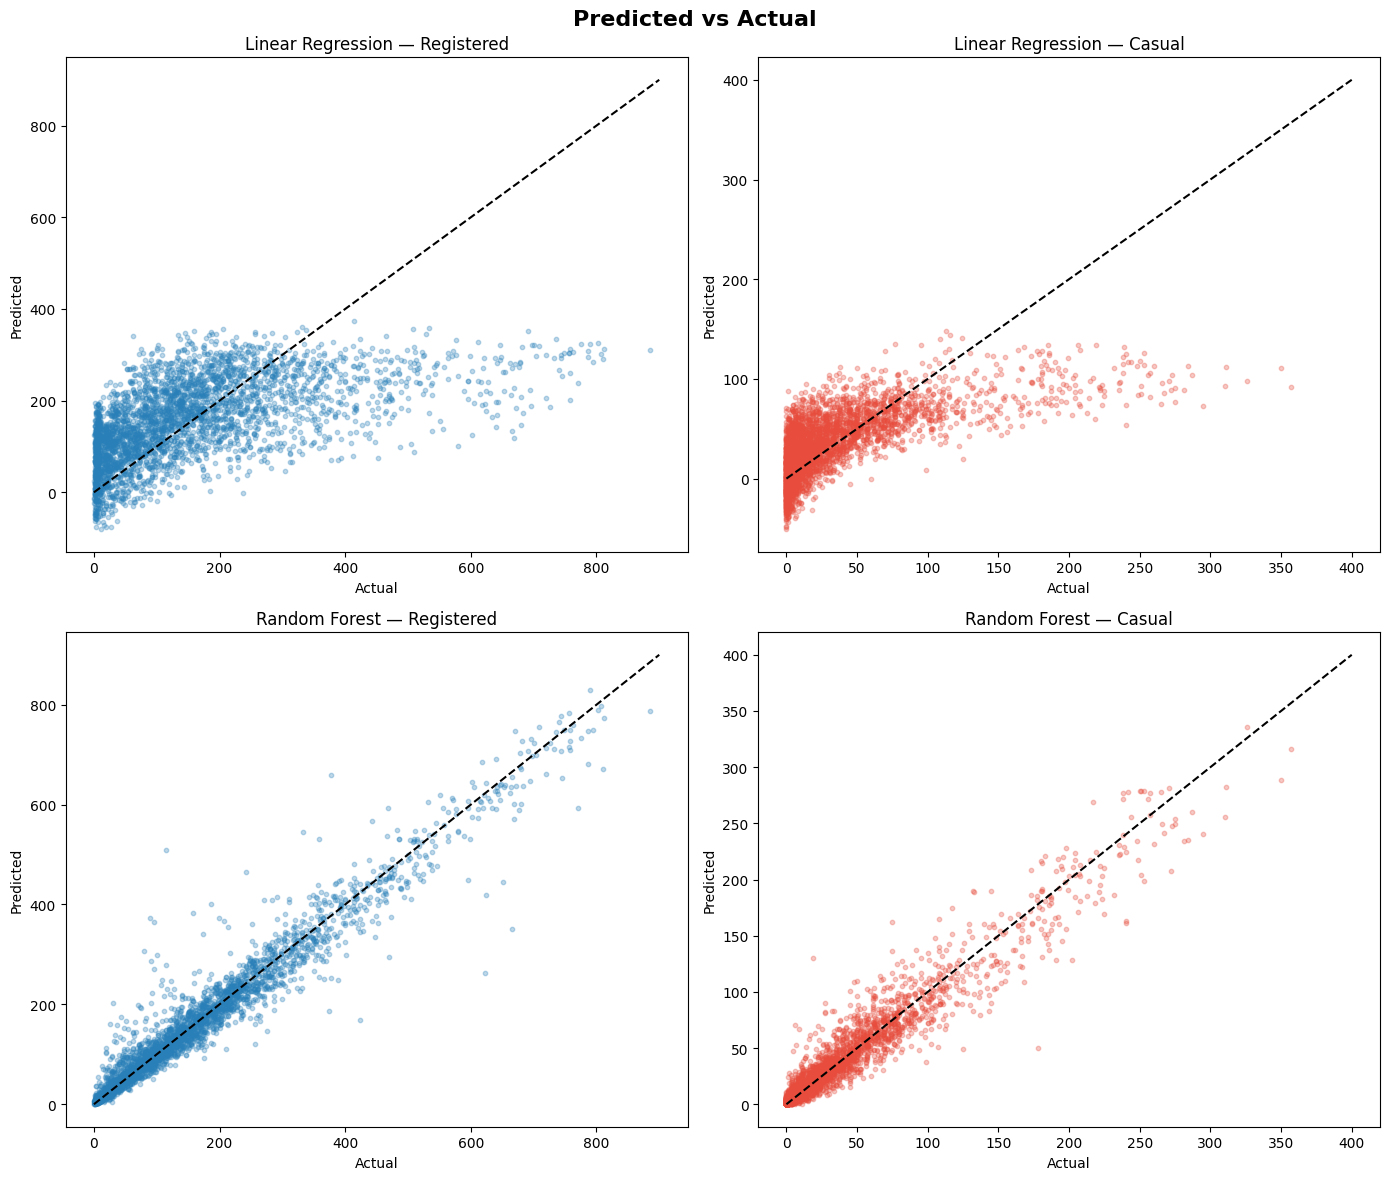

In [6]:
# Predicted vs actual
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Predicted vs Actual', fontsize=16, fontweight='bold')

axes[0, 0].scatter(y_reg_test, lr_reg_pred, alpha=0.3, s=10, color='#2980b9')
axes[0, 0].plot([0, 900], [0, 900], '--', color='black')
axes[0, 0].set_title('Linear Regression — Registered')
axes[0, 0].set_xlabel('Actual')
axes[0, 0].set_ylabel('Predicted')

axes[0, 1].scatter(y_cas_test, lr_cas_pred, alpha=0.3, s=10, color='#e74c3c')
axes[0, 1].plot([0, 400], [0, 400], '--', color='black')
axes[0, 1].set_title('Linear Regression — Casual')
axes[0, 1].set_xlabel('Actual')
axes[0, 1].set_ylabel('Predicted')

axes[1, 0].scatter(y_reg_test, rf_reg_pred, alpha=0.3, s=10, color='#2980b9')
axes[1, 0].plot([0, 900], [0, 900], '--', color='black')
axes[1, 0].set_title('Random Forest — Registered')
axes[1, 0].set_xlabel('Actual')
axes[1, 0].set_ylabel('Predicted')

axes[1, 1].scatter(y_cas_test, rf_cas_pred, alpha=0.3, s=10, color='#e74c3c')
axes[1, 1].plot([0, 400], [0, 400], '--', color='black')
axes[1, 1].set_title('Random Forest — Casual')
axes[1, 1].set_xlabel('Actual')
axes[1, 1].set_ylabel('Predicted')

plt.tight_layout()
plt.show()


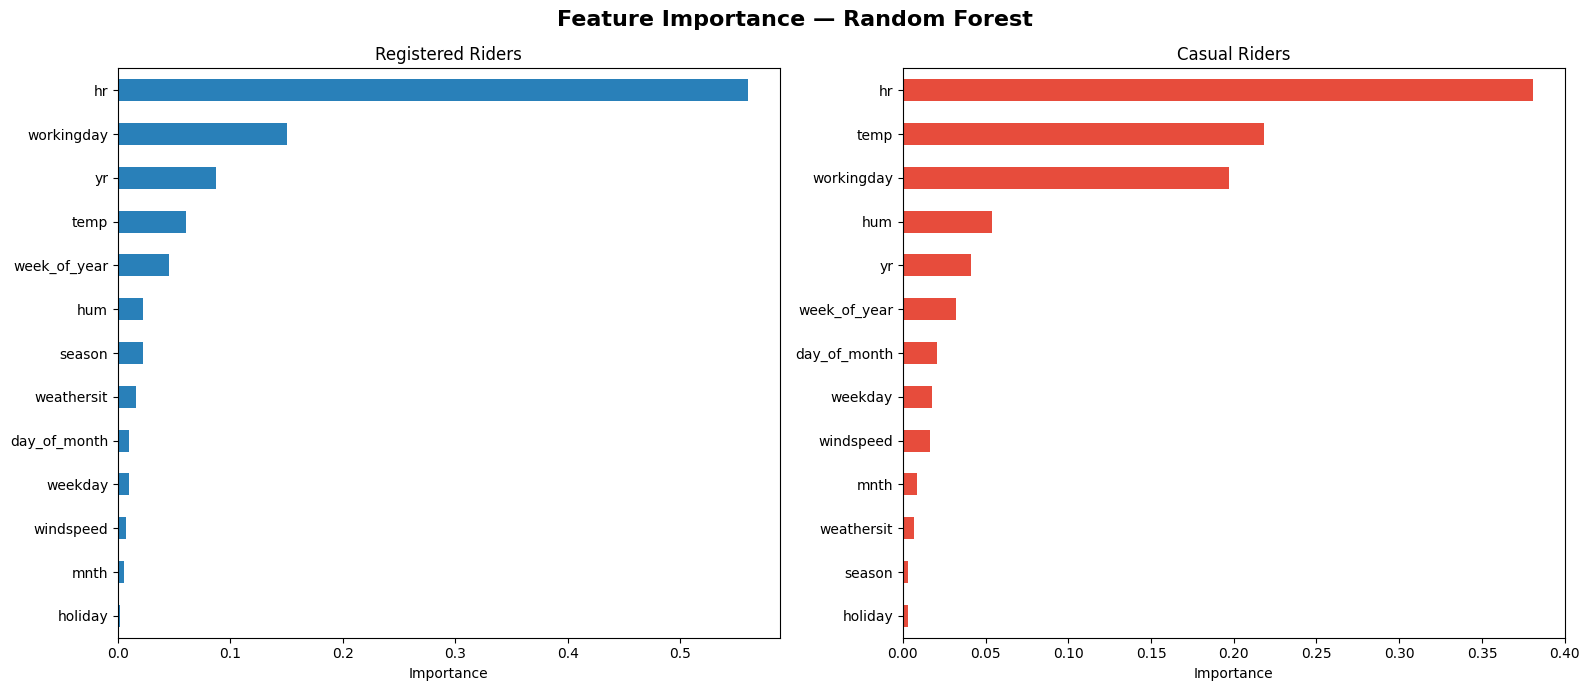

In [7]:
# Feature importance from Random Forest
cas_importance = pd.Series(rf_casual.feature_importances_, index=feature_columns).sort_values()
reg_importance = pd.Series(rf_registered.feature_importances_, index=feature_columns).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Feature Importance — Random Forest', fontsize=16, fontweight='bold')

reg_importance.plot(kind='barh', ax=axes[0], color='#2980b9')
axes[0].set_title('Registered Riders')
axes[0].set_xlabel('Importance')

cas_importance.plot(kind='barh', ax=axes[1], color='#e74c3c')
axes[1].set_title('Casual Riders')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

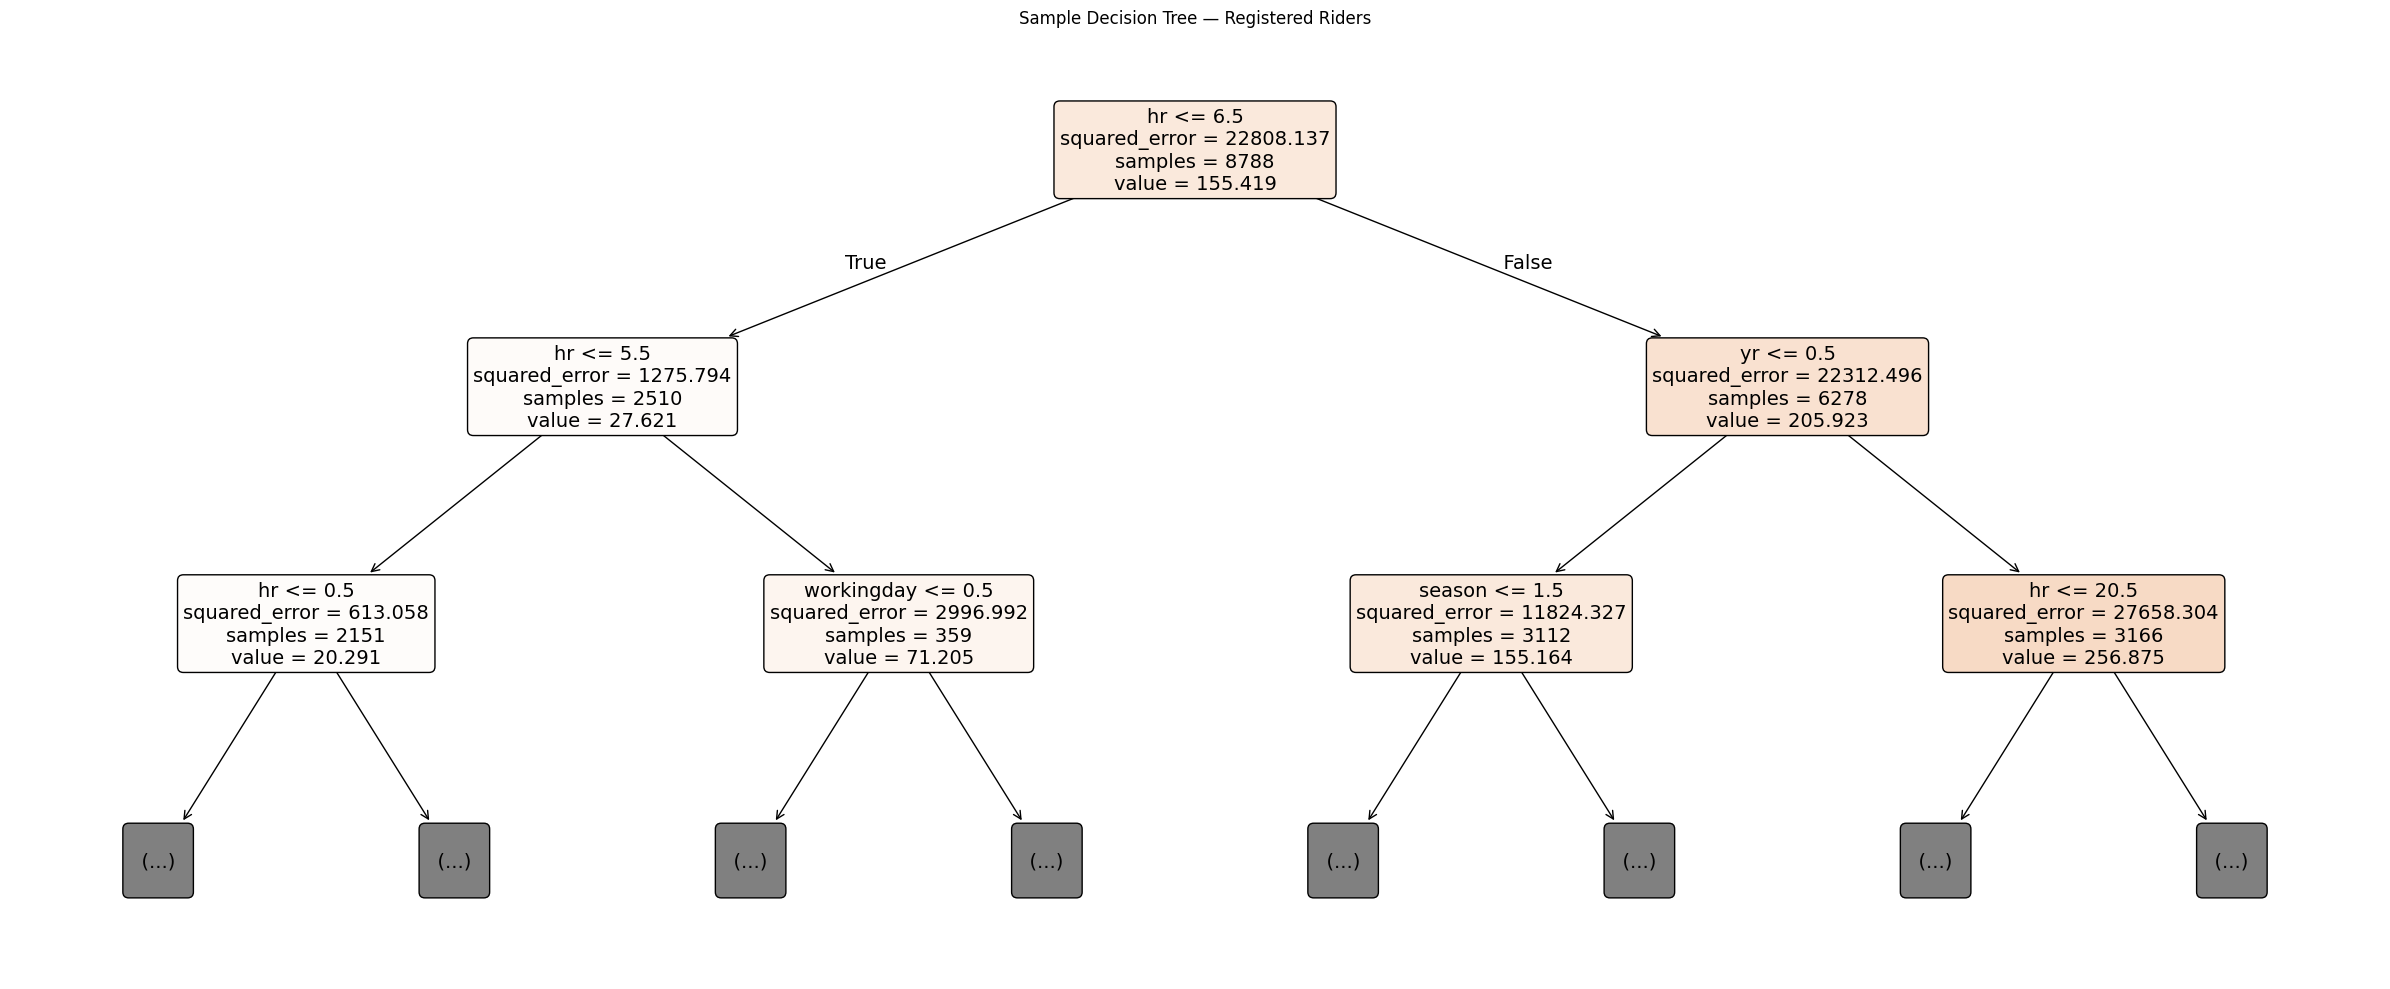

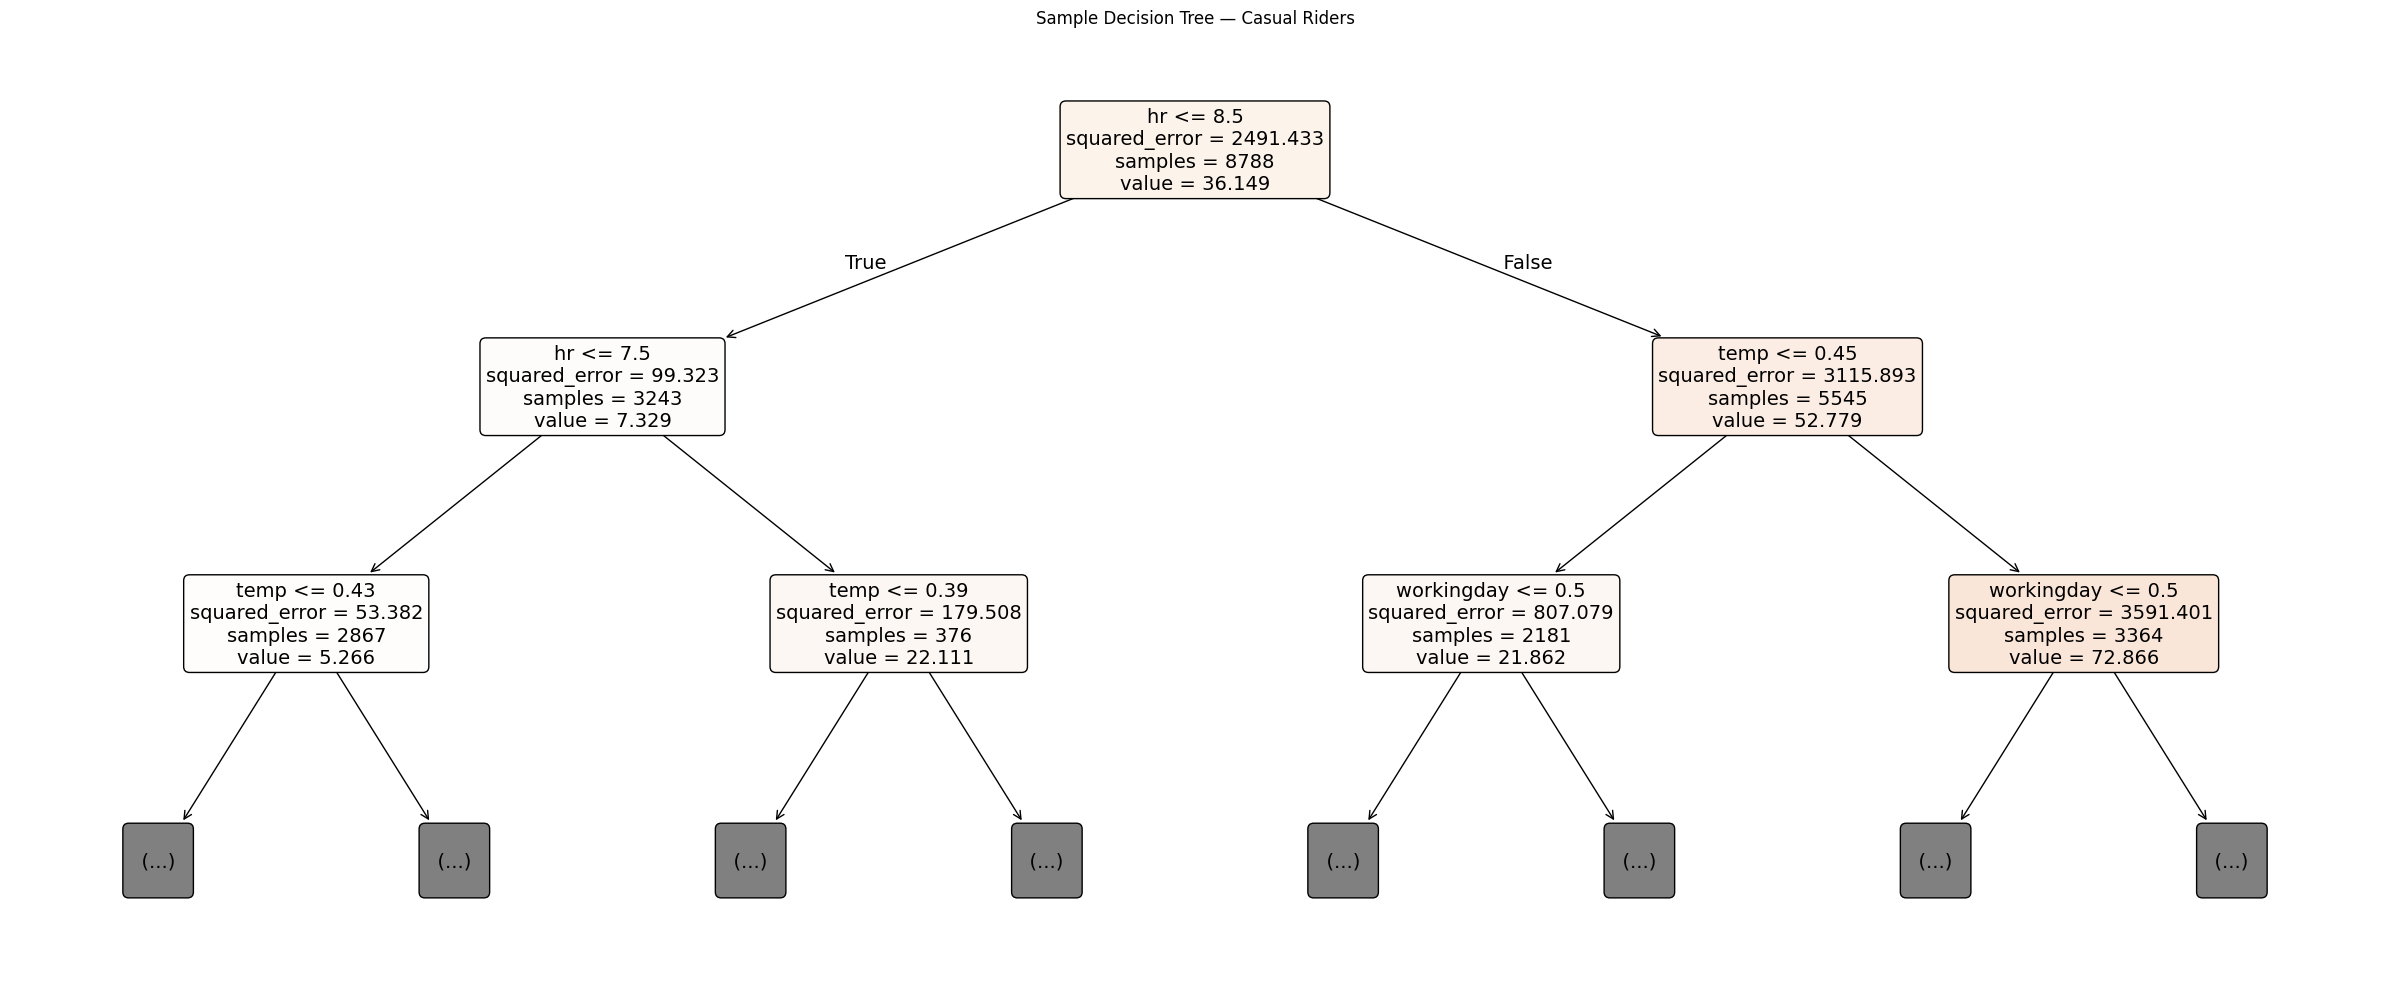

In [8]:
from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(24, 10))
plot_tree(rf_registered.estimators_[0],
          feature_names=feature_columns,
          max_depth=2,
          filled=True,
          rounded=True,
          fontsize=14,
          ax=ax)
plt.title('Sample Decision Tree — Registered Riders')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(24, 10))
plot_tree(rf_casual.estimators_[0],
          feature_names=feature_columns,
          max_depth=2,
          filled=True,
          rounded=True,
          fontsize=14,
          ax=ax)
plt.title('Sample Decision Tree — Casual Riders')
plt.tight_layout()
plt.show()

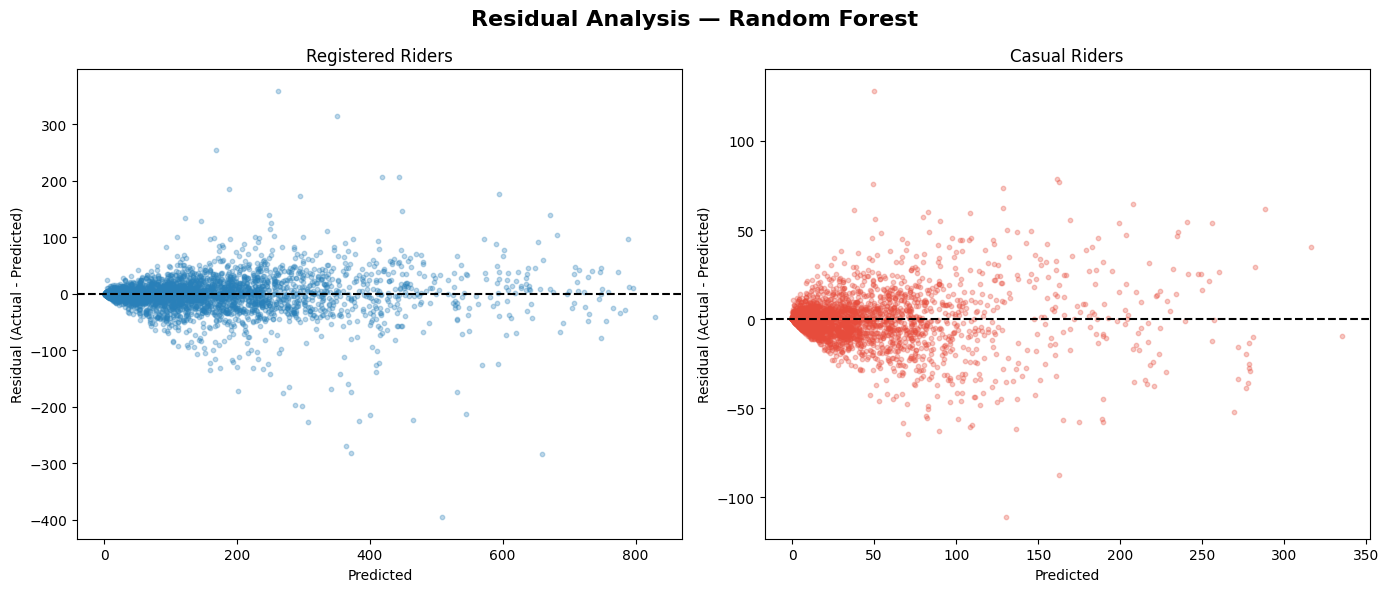

In [9]:
# Residuals = actual - predicted


rf_cas_residuals = y_cas_test - rf_cas_pred
rf_reg_residuals = y_reg_test - rf_reg_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Residual Analysis — Random Forest', fontsize=16, fontweight='bold')

axes[0].scatter(rf_reg_pred, rf_reg_residuals, alpha=0.3, s=10, color='#2980b9')
axes[0].axhline(y=0, color='black', linestyle='--')
axes[0].set_title('Registered Riders')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Residual (Actual - Predicted)')

axes[1].scatter(rf_cas_pred, rf_cas_residuals, alpha=0.3, s=10, color='#e74c3c')
axes[1].axhline(y=0, color='black', linestyle='--')
axes[1].set_title('Casual Riders')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Residual (Actual - Predicted)')

plt.tight_layout()
plt.show()

In [10]:
# Gradient Boosting

# Gradient Boosting builds trees one at a time, in sequence.
# Each new tree tries to fix the mistakes of the previous ones.
# Each tree focuses on the rows where the model is still getting it wrong.

from sklearn.ensemble import GradientBoostingRegressor

# Casual model
gb_casual = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_casual.fit(X_train, y_cas_train)
gb_cas_pred = gb_casual.predict(X_test)

# Registered model
gb_registered = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_registered.fit(X_train, y_reg_train)
gb_reg_pred = gb_registered.predict(X_test)

# Results
print("GRADIENT BOOSTING — CASUAL")
print("R2:", round(r2_score(y_cas_test, gb_cas_pred), 4),
      " RMSE:", round(np.sqrt(mean_squared_error(y_cas_test, gb_cas_pred)), 2),
      " MAE:", round(mean_absolute_error(y_cas_test, gb_cas_pred), 2))

print("\nGRADIENT BOOSTING — REGISTERED")
print("R2:", round(r2_score(y_reg_test, gb_reg_pred), 4),
      " RMSE:", round(np.sqrt(mean_squared_error(y_reg_test, gb_reg_pred)), 2),
      " MAE:", round(mean_absolute_error(y_reg_test, gb_reg_pred), 2))

GRADIENT BOOSTING — CASUAL
R2: 0.828  RMSE: 19.88  MAE: 11.65

GRADIENT BOOSTING — REGISTERED
R2: 0.8547  RMSE: 56.63  MAE: 38.2


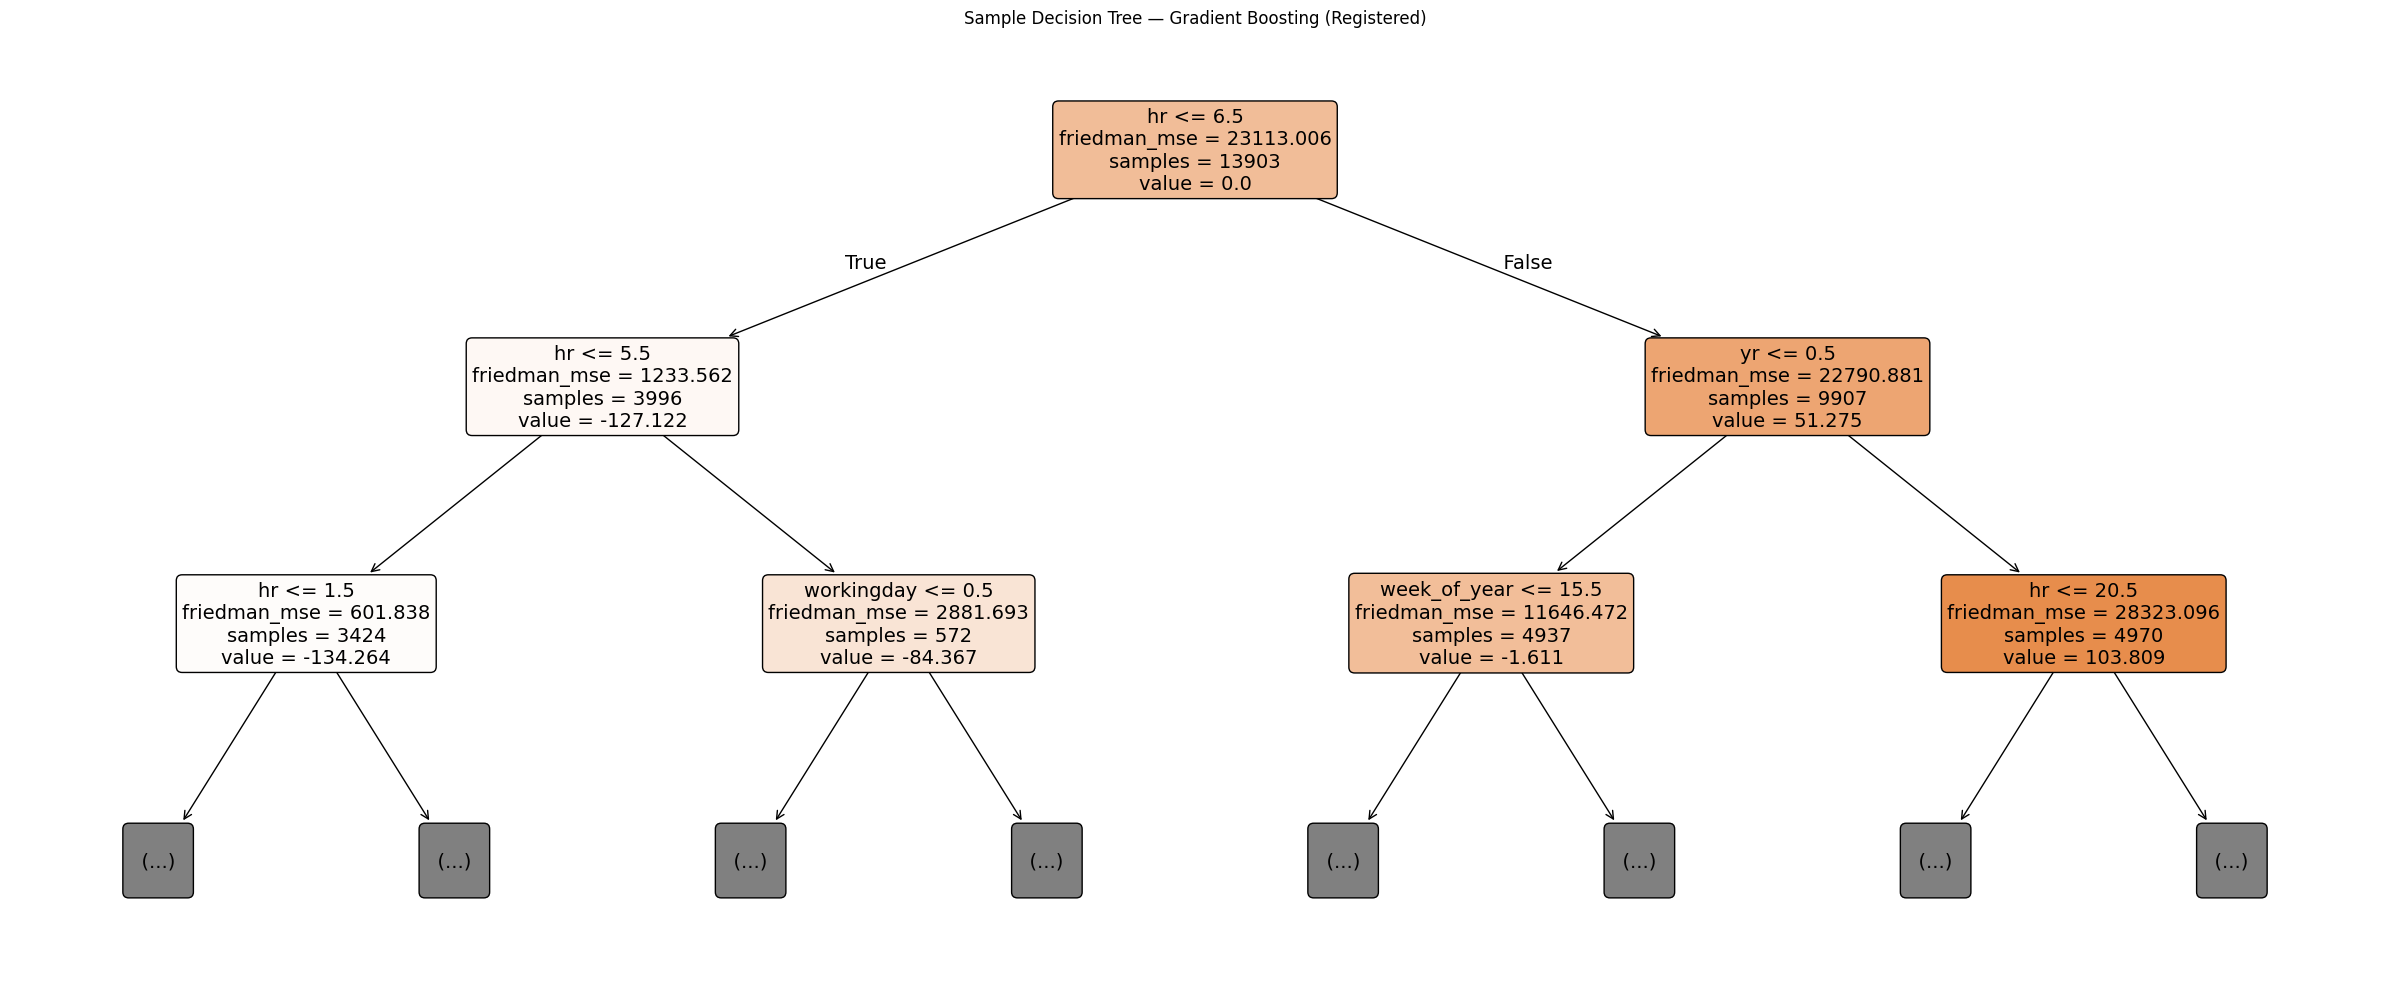

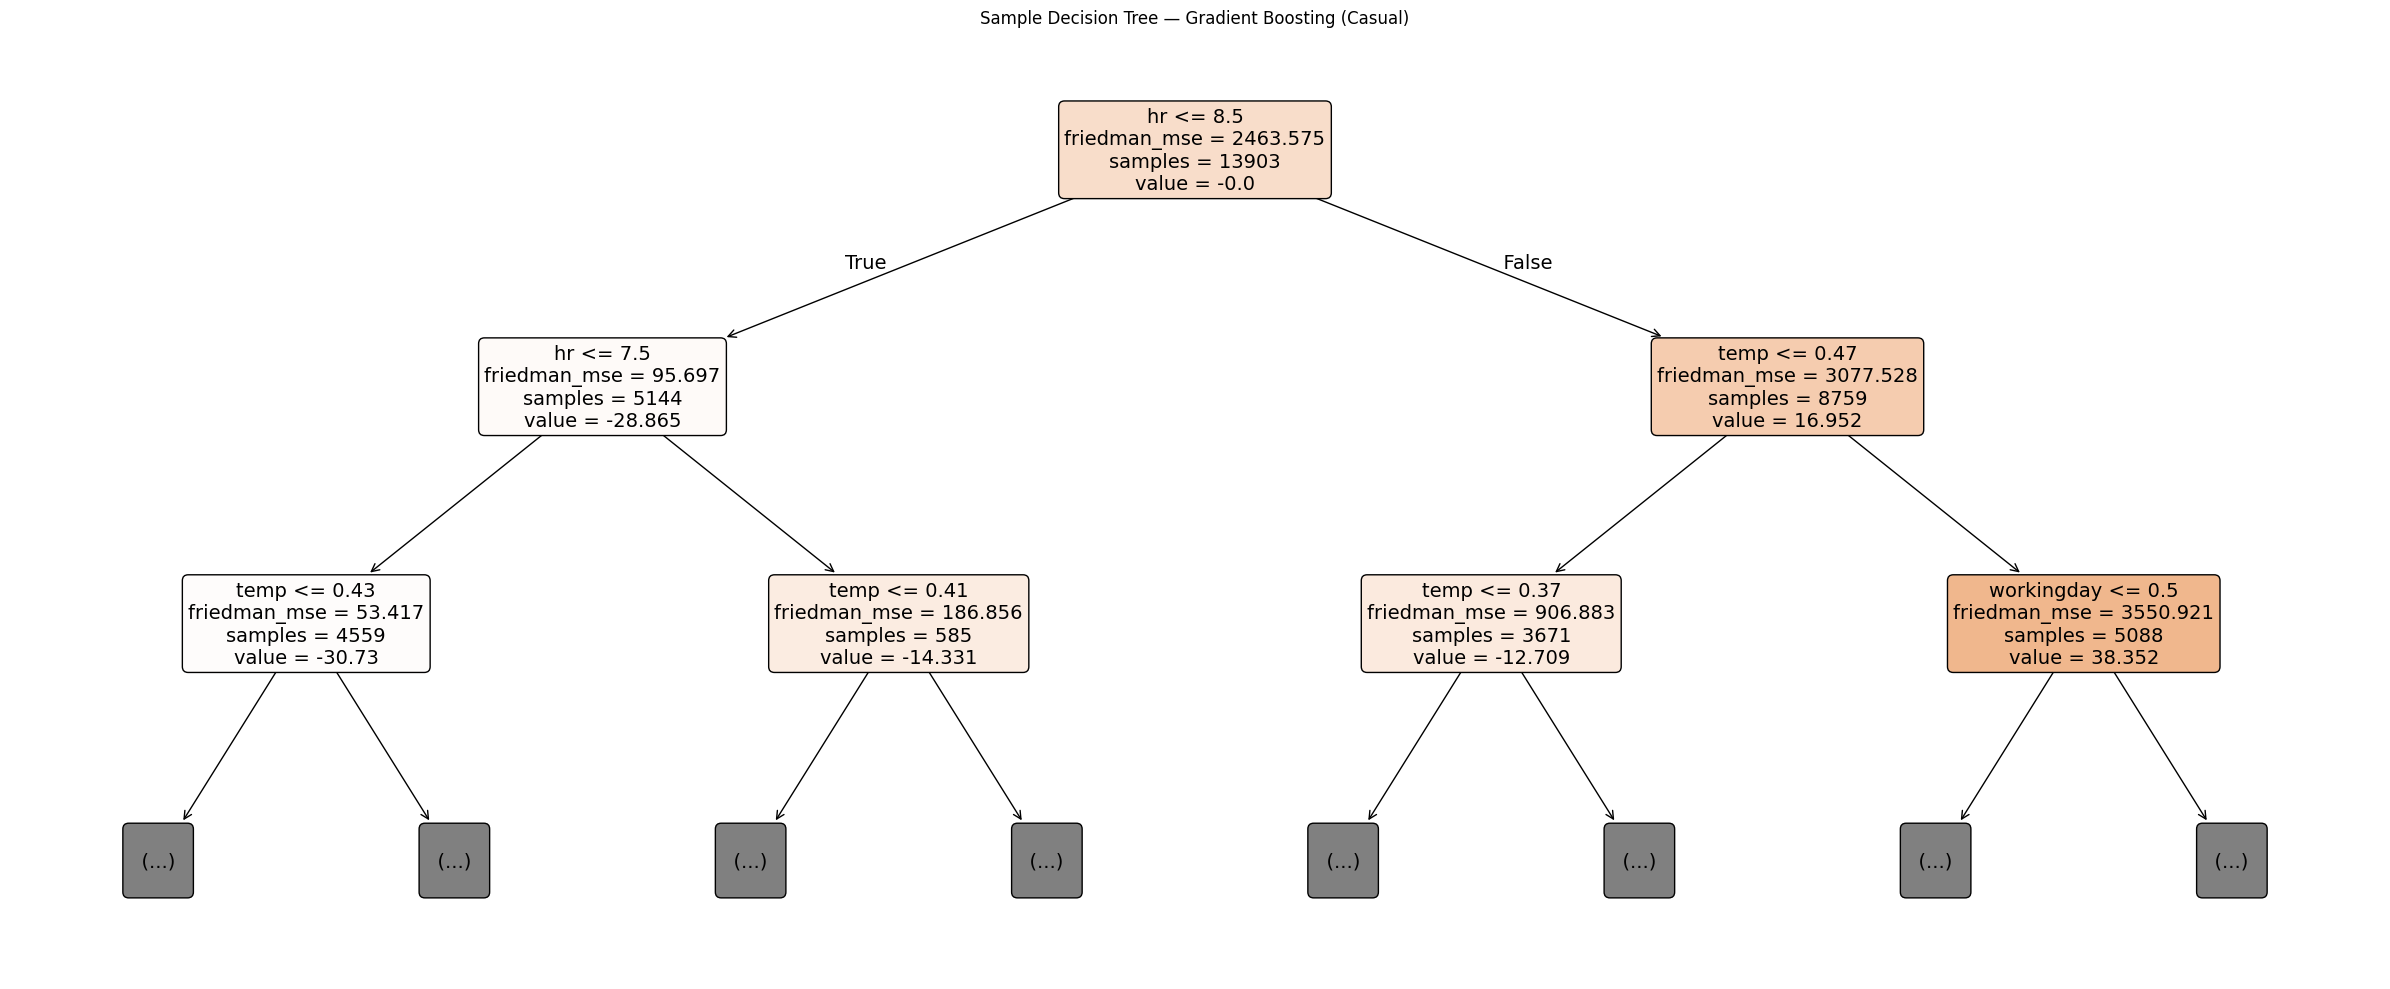

In [11]:
#looking at the tree

from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(24, 10))
plot_tree(gb_registered.estimators_[0, 0],
          feature_names=feature_columns,
          max_depth=2,
          filled=True,
          rounded=True,
          fontsize=14,
          ax=ax)
plt.title('Sample Decision Tree — Gradient Boosting (Registered)')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(24, 10))
plot_tree(gb_casual.estimators_[0, 0],
          feature_names=feature_columns,
          max_depth=2,
          filled=True,
          rounded=True,
          fontsize=14,
          ax=ax)
plt.title('Sample Decision Tree — Gradient Boosting (Casual)')
plt.tight_layout()
plt.show()

In [21]:
# Stacked Ensemble

#  Get predictions from base models on the FULL dataset

rf_full_cas = rf_casual.predict(X)
gb_full_cas = gb_casual.predict(X)
rf_full_reg = rf_registered.predict(X)
gb_full_reg = gb_registered.predict(X)

#adding 3d model
lr_full_cas = lr_casual.predict(X)
lr_full_reg = lr_registered.predict(X)


# Add predictions as new columns to the original features
X_stack_cas = X.copy()
X_stack_cas['rf_pred'] = rf_full_cas
X_stack_cas['gb_pred'] = gb_full_cas
#adding LR
X_stack_cas['lr_pred'] = lr_full_cas


X_stack_reg = X.copy()
X_stack_reg['rf_pred'] = rf_full_reg
X_stack_reg['gb_pred'] = gb_full_reg
#adding LR
X_stack_reg['lr_pred'] = lr_full_reg

# Re-split using the same random state
X_stack_cas_train, X_stack_cas_test, y_cas_train2, y_cas_test2 = train_test_split(
    X_stack_cas, y_casual, test_size=0.2, random_state=42)
X_stack_reg_train, X_stack_reg_test, y_reg_train2, y_reg_test2 = train_test_split(
    X_stack_reg, y_registered, test_size=0.2, random_state=42)

# Train meta-model on expanded features
stack_casual = RandomForestRegressor(n_estimators=100, random_state=42)
stack_casual.fit(X_stack_cas_train, y_cas_train2)
stack_cas_pred = stack_casual.predict(X_stack_cas_test)

stack_registered = RandomForestRegressor(n_estimators=100, random_state=42)
stack_registered.fit(X_stack_reg_train, y_reg_train2)
stack_reg_pred = stack_registered.predict(X_stack_reg_test)

#  Results
print("STACKED ENSEMBLE — CASUAL RIDERS")
print("R2:", round(r2_score(y_cas_test2, stack_cas_pred), 4),
      " RMSE:", round(np.sqrt(mean_squared_error(y_cas_test2, stack_cas_pred)), 2),
      " MAE:", round(mean_absolute_error(y_cas_test2, stack_cas_pred), 2))

print("\nSTACKED ENSEMBLE — REGISTERED RIDERS")
print("R2:", round(r2_score(y_reg_test2, stack_reg_pred), 4),
      " RMSE:", round(np.sqrt(mean_squared_error(y_reg_test2, stack_reg_pred)), 2),
      " MAE:", round(mean_absolute_error(y_reg_test2, stack_reg_pred), 2))

STACKED ENSEMBLE — CASUAL RIDERS
R2: 0.9233  RMSE: 13.28  MAE: 7.85

STACKED ENSEMBLE — REGISTERED RIDERS
R2: 0.9452  RMSE: 34.78  MAE: 19.75


In [22]:
# 3 models comparison

print("MODEL COMPARISON — CASUAL RIDERS")
print("Linear Regression  R2:", round(r2_score(y_cas_test, lr_cas_pred), 4),
      " RMSE:", round(np.sqrt(mean_squared_error(y_cas_test, lr_cas_pred)), 2),
      " MAE:", round(mean_absolute_error(y_cas_test, lr_cas_pred), 2))
print("Random Forest      R2:", round(r2_score(y_cas_test, rf_cas_pred), 4),
      " RMSE:", round(np.sqrt(mean_squared_error(y_cas_test, rf_cas_pred)), 2),
      " MAE:", round(mean_absolute_error(y_cas_test, rf_cas_pred), 2))
print("Ensemble model     R2:", round(r2_score(y_cas_test2, stack_cas_pred), 4),
      " RMSE:", round(np.sqrt(mean_squared_error(y_cas_test2, stack_cas_pred)), 2),
      " MAE:", round(mean_absolute_error(y_cas_test2, stack_cas_pred), 2))

print("\nMODEL COMPARISON — REGISTERED RIDERS")
print("Linear Regression  R2:", round(r2_score(y_reg_test, lr_reg_pred), 4),
      " RMSE:", round(np.sqrt(mean_squared_error(y_reg_test, lr_reg_pred)), 2),
      " MAE:", round(mean_absolute_error(y_reg_test, lr_reg_pred), 2))
print("Random Forest      R2:", round(r2_score(y_reg_test, rf_reg_pred), 4),
      " RMSE:", round(np.sqrt(mean_squared_error(y_reg_test, rf_reg_pred)), 2),
      " MAE:", round(mean_absolute_error(y_reg_test, rf_reg_pred), 2))
print("Ensemble model     R2:", round(r2_score(y_reg_test2, stack_reg_pred), 4),
      " RMSE:", round(np.sqrt(mean_squared_error(y_reg_test2, stack_reg_pred)), 2),
      " MAE:", round(mean_absolute_error(y_reg_test2, stack_reg_pred), 2))

MODEL COMPARISON — CASUAL RIDERS
Linear Regression  R2: 0.4567  RMSE: 35.33  MAE: 23.86
Random Forest      R2: 0.926  RMSE: 13.04  MAE: 7.73
Ensemble model     R2: 0.9233  RMSE: 13.28  MAE: 7.85

MODEL COMPARISON — REGISTERED RIDERS
Linear Regression  R2: 0.3291  RMSE: 121.7  MAE: 88.9
Random Forest      R2: 0.9479  RMSE: 33.93  MAE: 19.42
Ensemble model     R2: 0.9452  RMSE: 34.78  MAE: 19.75
